# ME1: Three-layer CNN for MNIST using Einops and Einsum

**Student:** Crizepvill Dumalaog

**Course:** AI 231

**Training requirement:** exactly five epochs on the official MNIST
training split, followed by one report on the official test split.

## Agent disclosure

A coding agent created the repository structure, manual implementation,
tests, notebook, training run, plots, Git history, and GitHub repository.
The student is still responsible for inspecting and understanding every
operation, tensor shape, result, and limitation before submission.

## Restrictions

This notebook uses no CNN library and no PyTorch neural-network layer
API. There is no built-in convolution, pooling, flatten, linear,
activation, or loss layer. The three convolutional stages use a strided
tensor window view, `einops.rearrange`, and `torch.einsum`; pooling uses
`einops.reduce`; dense transformations use `einsum`; and cross-entropy
is written directly from log-sum-exp. Torchvision is used only to
download/read MNIST—not for a model, transform, or CNN operation. No NLP
library or NLP operation is involved.

## How the manual convolution works

For input $X$ and kernel $W$, an overlapping view exposes patches with
shape `(batch, in_channel, out_h, out_w, kernel_h, kernel_w)`.
Einops flattens the last three patch axes and the corresponding kernel
axes. The learned cross-correlation is then

$$Y_{b,h,w,o}=\sum_p X^{patch}_{b,h,w,p}W^{flat}_{p,o}+b_o.$$

`einsum("bhwp,po->bhwo", patches, kernels)` performs exactly that
contraction. Autograd follows the view, rearrangement, reduction, and
contraction back to each ordinary leaf tensor parameter.

In [1]:
from pathlib import Path
import sys

candidates = [
    Path.cwd(),
    Path.cwd() / "ME1_CNN_Einops",
    Path.cwd() / "AI 231" / "ME1_CNN_Einops",
]
PROJECT_ROOT = next(
    path.resolve() for path in candidates
    if (path / "src" / "manual_cnn.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"Project: {PROJECT_ROOT}")
print(f"Python: {sys.version.split()[0]}")

Project: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\ME1_CNN_Einops
Python: 3.12.10


## Manual layer and model implementation

The complete checked-in implementation is included in this code cell so
the submission can be inspected directly. It intentionally contains no
PyTorch neural-network layer import.

In [2]:
"""Manual three-convolution-layer MNIST model using tensors, Einops, and einsum.

This module deliberately avoids torch.nn, torch.nn.functional, and every
built-in convolution/pooling/linear/loss layer. Parameters are ordinary leaf
tensors tracked by autograd and updated by a standard optimizer.
"""

from __future__ import annotations

from dataclasses import asdict, dataclass
import math
from typing import Iterable

from einops import rearrange, reduce
import torch


def _pair(value: int | tuple[int, int]) -> tuple[int, int]:
    """Normalize a scalar or pair and reject non-positive dimensions."""

    pair = (value, value) if isinstance(value, int) else tuple(value)
    if len(pair) != 2 or pair[0] <= 0 or pair[1] <= 0:
        raise ValueError(f"Expected a positive integer or pair, received {value!r}.")
    return int(pair[0]), int(pair[1])


def manual_pad2d(x: torch.Tensor, padding: int | tuple[int, int]) -> torch.Tensor:
    """Zero-pad the final two dimensions using basic tensor allocation/copy."""

    pad_h, pad_w = (padding, padding) if isinstance(padding, int) else tuple(padding)
    if pad_h < 0 or pad_w < 0:
        raise ValueError("Padding cannot be negative.")
    if pad_h == 0 and pad_w == 0:
        return x
    if x.ndim != 4:
        raise ValueError(f"Expected BCHW input, received shape {tuple(x.shape)}.")

    batch, channels, height, width = x.shape
    padded = x.new_zeros(
        (batch, channels, height + 2 * pad_h, width + 2 * pad_w)
    )
    padded[:, :, pad_h : pad_h + height, pad_w : pad_w + width] = x
    return padded


def sliding_windows_2d(
    x: torch.Tensor,
    kernel_size: int | tuple[int, int],
    stride: int | tuple[int, int] = 1,
) -> torch.Tensor:
    """Return a BCHW-compatible overlapping window view using ``as_strided``.

    Output shape is ``(batch, channels, out_h, out_w, kernel_h, kernel_w)``.
    No convolution helper or unfold layer is used.
    """

    if x.ndim != 4:
        raise ValueError(f"Expected BCHW input, received shape {tuple(x.shape)}.")
    kernel_h, kernel_w = _pair(kernel_size)
    stride_h, stride_w = _pair(stride)
    batch, channels, height, width = x.shape
    if kernel_h > height or kernel_w > width:
        raise ValueError("Kernel cannot be larger than the padded input.")

    out_h = 1 + (height - kernel_h) // stride_h
    out_w = 1 + (width - kernel_w) // stride_w
    stride_b, stride_c, stride_y, stride_x = x.stride()
    shape = (batch, channels, out_h, out_w, kernel_h, kernel_w)
    strides = (
        stride_b,
        stride_c,
        stride_y * stride_h,
        stride_x * stride_w,
        stride_y,
        stride_x,
    )
    return x.as_strided(size=shape, stride=strides)


def manual_conv2d(
    x: torch.Tensor,
    weight: torch.Tensor,
    bias: torch.Tensor,
    *,
    stride: int | tuple[int, int] = 1,
    padding: int | tuple[int, int] = 0,
) -> torch.Tensor:
    """Apply a learned 2-D cross-correlation via strided views and ``einsum``."""

    if x.ndim != 4 or weight.ndim != 4 or bias.ndim != 1:
        raise ValueError("Expected x=BCHW, weight=OIKK, and bias=O tensors.")
    out_channels, in_channels, kernel_h, kernel_w = weight.shape
    if x.shape[1] != in_channels:
        raise ValueError(
            f"Input has {x.shape[1]} channels but kernel expects {in_channels}."
        )
    if bias.shape[0] != out_channels:
        raise ValueError("Bias length must equal the number of output channels.")

    padded = manual_pad2d(x, padding)
    windows = sliding_windows_2d(padded, (kernel_h, kernel_w), stride)
    patches = rearrange(
        windows,
        "batch channel out_h out_w kernel_h kernel_w -> "
        "batch out_h out_w (channel kernel_h kernel_w)",
    )
    flat_kernels = rearrange(
        weight,
        "out_channel in_channel kernel_h kernel_w -> "
        "(in_channel kernel_h kernel_w) out_channel",
    )
    output = torch.einsum("bhwp,po->bhwo", patches, flat_kernels)
    output = output + bias
    return rearrange(output, "batch out_h out_w channel -> batch channel out_h out_w")


def manual_relu(x: torch.Tensor) -> torch.Tensor:
    """Elementwise ReLU without a neural-network activation module."""

    return torch.where(x > 0, x, torch.zeros_like(x))


def manual_max_pool2d(
    x: torch.Tensor, pool_size: int | tuple[int, int] = 2
) -> torch.Tensor:
    """Non-overlapping max pooling implemented by ``einops.reduce``."""

    pool_h, pool_w = _pair(pool_size)
    if x.ndim != 4:
        raise ValueError(f"Expected BCHW input, received shape {tuple(x.shape)}.")
    if x.shape[-2] % pool_h or x.shape[-1] % pool_w:
        raise ValueError("Spatial dimensions must be divisible by the pool size.")
    return reduce(
        x,
        "batch channel (out_h pool_h) (out_w pool_w) -> batch channel out_h out_w",
        "max",
        pool_h=pool_h,
        pool_w=pool_w,
    )


def manual_flatten(x: torch.Tensor) -> torch.Tensor:
    """Flatten all non-batch axes using Einops."""

    return rearrange(x, "batch ... -> batch (...)")


def manual_linear(
    x: torch.Tensor, weight: torch.Tensor, bias: torch.Tensor
) -> torch.Tensor:
    """Dense transformation implemented as an ``einsum`` contraction."""

    if x.ndim != 2 or weight.ndim != 2 or bias.ndim != 1:
        raise ValueError("Expected x=BI, weight=IO, and bias=O tensors.")
    if x.shape[1] != weight.shape[0] or weight.shape[1] != bias.shape[0]:
        raise ValueError("Incompatible dense-layer tensor shapes.")
    return torch.einsum("bi,io->bo", x, weight) + bias


def manual_cross_entropy(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Mean multiclass negative log likelihood using log-sum-exp stabilization."""

    if logits.ndim != 2 or targets.ndim != 1 or logits.shape[0] != targets.shape[0]:
        raise ValueError("Expected logits=(batch, classes) and targets=(batch,).")
    log_probabilities = logits - torch.logsumexp(logits, dim=1, keepdim=True)
    rows = torch.arange(targets.shape[0], device=targets.device)
    return -log_probabilities[rows, targets].mean()


def classification_accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
    """Return the fraction of correct class predictions."""

    return float((logits.argmax(dim=1) == targets).float().mean().item())


@dataclass(frozen=True)
class ManualCNNConfig:
    """Architecture definition for the three-convolution-stage model."""

    input_channels: int = 1
    image_size: int = 28
    conv1_channels: int = 8
    conv2_channels: int = 16
    conv3_channels: int = 32
    hidden_features: int = 64
    classes: int = 10


class ManualThreeLayerCNN:
    """Three convolutional stages and an einsum classifier without layer APIs."""

    def __init__(
        self,
        config: ManualCNNConfig | None = None,
        *,
        seed: int = 42,
        device: str | torch.device = "cpu",
    ) -> None:
        self.config = config or ManualCNNConfig()
        self.device = torch.device(device)
        generator = torch.Generator(device="cpu").manual_seed(seed)

        c = self.config
        flattened_features = c.conv3_channels * (c.image_size // 4) ** 2
        self.conv1_weight = self._weight(
            (c.conv1_channels, c.input_channels, 5, 5),
            c.input_channels * 5 * 5,
            generator,
        )
        self.conv1_bias = self._bias(c.conv1_channels)
        self.conv2_weight = self._weight(
            (c.conv2_channels, c.conv1_channels, 3, 3),
            c.conv1_channels * 3 * 3,
            generator,
        )
        self.conv2_bias = self._bias(c.conv2_channels)
        self.conv3_weight = self._weight(
            (c.conv3_channels, c.conv2_channels, 3, 3),
            c.conv2_channels * 3 * 3,
            generator,
        )
        self.conv3_bias = self._bias(c.conv3_channels)
        self.hidden_weight = self._weight(
            (flattened_features, c.hidden_features),
            flattened_features,
            generator,
        )
        self.hidden_bias = self._bias(c.hidden_features)
        self.output_weight = self._weight(
            (c.hidden_features, c.classes), c.hidden_features, generator
        )
        self.output_bias = self._bias(c.classes)

    def _weight(
        self,
        shape: tuple[int, ...],
        fan_in: int,
        generator: torch.Generator,
    ) -> torch.Tensor:
        values = torch.randn(shape, generator=generator) * math.sqrt(2.0 / fan_in)
        return values.to(self.device).requires_grad_(True)

    def _bias(self, features: int) -> torch.Tensor:
        return torch.zeros(features, device=self.device, requires_grad=True)

    def named_parameters(self) -> list[tuple[str, torch.Tensor]]:
        """Return stable parameter names and their leaf tensors."""

        names = (
            "conv1_weight",
            "conv1_bias",
            "conv2_weight",
            "conv2_bias",
            "conv3_weight",
            "conv3_bias",
            "hidden_weight",
            "hidden_bias",
            "output_weight",
            "output_bias",
        )
        return [(name, getattr(self, name)) for name in names]

    def parameters(self) -> Iterable[torch.Tensor]:
        """Yield tensors in the format expected by PyTorch optimizers."""

        return (parameter for _, parameter in self.named_parameters())

    def state_dict(self) -> dict[str, torch.Tensor]:
        """Return detached CPU copies suitable for checkpoints."""

        return {
            name: parameter.detach().cpu().clone()
            for name, parameter in self.named_parameters()
        }

    def load_state_dict(self, state: dict[str, torch.Tensor]) -> None:
        """Copy checkpoint values into the existing leaf tensors."""

        expected = {name for name, _ in self.named_parameters()}
        if set(state) != expected:
            raise ValueError(f"State keys do not match model parameters: {set(state) ^ expected}")
        with torch.no_grad():
            for name, parameter in self.named_parameters():
                parameter.copy_(state[name].to(self.device))

    def parameter_count(self) -> int:
        return sum(parameter.numel() for parameter in self.parameters())

    def architecture(self) -> dict[str, object]:
        return asdict(self.config) | {"trainable_parameters": self.parameter_count()}

    def forward_with_shapes(
        self, x: torch.Tensor
    ) -> tuple[torch.Tensor, dict[str, tuple[int, ...]]]:
        """Forward pass plus named shapes for notebook inspection."""

        shapes: dict[str, tuple[int, ...]] = {"input": tuple(x.shape)}
        x = manual_conv2d(x, self.conv1_weight, self.conv1_bias, padding=2)
        x = manual_relu(x)
        shapes["conv1_relu"] = tuple(x.shape)
        x = manual_max_pool2d(x, 2)
        shapes["pool1"] = tuple(x.shape)

        x = manual_conv2d(x, self.conv2_weight, self.conv2_bias, padding=1)
        x = manual_relu(x)
        shapes["conv2_relu"] = tuple(x.shape)
        x = manual_max_pool2d(x, 2)
        shapes["pool2"] = tuple(x.shape)

        x = manual_conv2d(x, self.conv3_weight, self.conv3_bias, padding=1)
        x = manual_relu(x)
        shapes["conv3_relu"] = tuple(x.shape)

        x = manual_flatten(x)
        shapes["flatten"] = tuple(x.shape)
        x = manual_linear(x, self.hidden_weight, self.hidden_bias)
        x = manual_relu(x)
        shapes["hidden_relu"] = tuple(x.shape)
        logits = manual_linear(x, self.output_weight, self.output_bias)
        shapes["logits"] = tuple(logits.shape)
        return logits, shapes

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        logits, _ = self.forward_with_shapes(x)
        return logits

## Data, training, evaluation, and visualization utilities

MNIST's official 60,000-image training split and 10,000-image test split
are loaded without augmentation. The test split is not used for model
selection or parameter updates.

In [3]:
"""MNIST data, training, evaluation, and visualization for ME1."""

from __future__ import annotations

from dataclasses import dataclass
import json
import os
from pathlib import Path
import random
import time

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
from torchvision.datasets import MNIST

from manual_cnn import ManualThreeLayerCNN, manual_cross_entropy


MNIST_MEAN = 0.1307
MNIST_STD = 0.3081


@dataclass(frozen=True)
class MNISTTensors:
    train_images: torch.Tensor
    train_labels: torch.Tensor
    test_images: torch.Tensor
    test_labels: torch.Tensor


def set_seed(seed: int = 42) -> None:
    # cuBLAS needs this workspace policy before its first CUDA operation when
    # deterministic algorithms are requested.
    os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
    random.seed(seed)
    torch.manual_seed(seed)
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def choose_device(requested: str = "auto") -> torch.device:
    if requested != "auto":
        return torch.device(requested)
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def _prepare_images(raw: torch.Tensor) -> torch.Tensor:
    images = raw.to(dtype=torch.float32).unsqueeze(1) / 255.0
    return (images - MNIST_MEAN) / MNIST_STD


def load_mnist(
    data_dir: str | Path,
    *,
    limit_train: int | None = None,
    limit_test: int | None = None,
) -> MNISTTensors:
    """Download/read official MNIST and return normalized BCHW tensors."""

    data_dir = Path(data_dir)
    training = MNIST(root=data_dir, train=True, download=True)
    testing = MNIST(root=data_dir, train=False, download=True)

    train_images = _prepare_images(training.data)
    train_labels = training.targets.to(dtype=torch.long)
    test_images = _prepare_images(testing.data)
    test_labels = testing.targets.to(dtype=torch.long)

    if limit_train is not None:
        train_images = train_images[:limit_train]
        train_labels = train_labels[:limit_train]
    if limit_test is not None:
        test_images = test_images[:limit_test]
        test_labels = test_labels[:limit_test]

    return MNISTTensors(train_images, train_labels, test_images, test_labels)


def _batch_indices(
    sample_count: int,
    batch_size: int,
    *,
    shuffle: bool,
    generator: torch.Generator,
) -> list[torch.Tensor]:
    order = (
        torch.randperm(sample_count, generator=generator)
        if shuffle
        else torch.arange(sample_count)
    )
    return list(order.split(batch_size))


@torch.no_grad()
def evaluate_model(
    model: ManualThreeLayerCNN,
    images: torch.Tensor,
    labels: torch.Tensor,
    *,
    batch_size: int = 512,
) -> dict[str, object]:
    generator = torch.Generator(device="cpu").manual_seed(0)
    total_loss = 0.0
    total_correct = 0
    predictions: list[torch.Tensor] = []

    for indices in _batch_indices(
        len(images), batch_size, shuffle=False, generator=generator
    ):
        batch_images = images[indices].to(model.device, non_blocking=True)
        batch_labels = labels[indices].to(model.device, non_blocking=True)
        logits = model(batch_images)
        loss = manual_cross_entropy(logits, batch_labels)
        batch_predictions = logits.argmax(dim=1)
        total_loss += float(loss.item()) * len(indices)
        total_correct += int((batch_predictions == batch_labels).sum().item())
        predictions.append(batch_predictions.cpu())

    return {
        "loss": total_loss / len(images),
        "accuracy": total_correct / len(images),
        "predictions": torch.cat(predictions),
    }


def train_model(
    model: ManualThreeLayerCNN,
    train_images: torch.Tensor,
    train_labels: torch.Tensor,
    *,
    epochs: int = 5,
    batch_size: int = 256,
    learning_rate: float = 1e-3,
    seed: int = 42,
) -> list[dict[str, float]]:
    """Train for exactly ``epochs`` passes and return epoch-level history."""

    if epochs <= 0:
        raise ValueError("epochs must be positive")
    optimizer = torch.optim.Adam(list(model.parameters()), lr=learning_rate)
    generator = torch.Generator(device="cpu").manual_seed(seed)
    history: list[dict[str, float]] = []

    for epoch in range(1, epochs + 1):
        started = time.perf_counter()
        total_loss = 0.0
        total_correct = 0

        for indices in _batch_indices(
            len(train_images), batch_size, shuffle=True, generator=generator
        ):
            batch_images = train_images[indices].to(model.device, non_blocking=True)
            batch_labels = train_labels[indices].to(model.device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_images)
            loss = manual_cross_entropy(logits, batch_labels)
            loss.backward()
            optimizer.step()

            total_loss += float(loss.detach().item()) * len(indices)
            total_correct += int((logits.detach().argmax(dim=1) == batch_labels).sum().item())

        if model.device.type == "cuda":
            torch.cuda.synchronize(model.device)
        epoch_result = {
            "epoch": float(epoch),
            "train_loss": total_loss / len(train_images),
            "train_accuracy": total_correct / len(train_images),
            "seconds": time.perf_counter() - started,
        }
        history.append(epoch_result)
        print(
            f"Epoch {epoch}/{epochs} | "
            f"loss={epoch_result['train_loss']:.4f} | "
            f"accuracy={epoch_result['train_accuracy'] * 100:.2f}% | "
            f"time={epoch_result['seconds']:.1f}s"
        )

    return history


def confusion_matrix(
    targets: torch.Tensor, predictions: torch.Tensor, classes: int = 10
) -> torch.Tensor:
    encoded = targets.to(torch.long) * classes + predictions.to(torch.long)
    return torch.bincount(encoded, minlength=classes * classes).reshape(classes, classes)


def save_training_curves(
    history: list[dict[str, float]], output_path: str | Path
) -> Path:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    epochs = [int(item["epoch"]) for item in history]
    losses = [item["train_loss"] for item in history]
    accuracies = [item["train_accuracy"] * 100 for item in history]

    figure, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(epochs, losses, marker="o")
    axes[0].set(title="Training loss", xlabel="Epoch", ylabel="Cross-entropy")
    axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, accuracies, marker="o", color="tab:green")
    axes[1].set(title="Training accuracy", xlabel="Epoch", ylabel="Accuracy (%)")
    axes[1].grid(alpha=0.3)
    figure.tight_layout()
    figure.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(figure)
    return output_path


def save_prediction_grid(
    images: torch.Tensor,
    labels: torch.Tensor,
    predictions: torch.Tensor,
    output_path: str | Path,
    *,
    seed: int = 2026,
) -> tuple[Path, list[int]]:
    """Save 16 deterministic test samples in a 4×4 GT/prediction grid."""

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    generator = torch.Generator(device="cpu").manual_seed(seed)
    selected = torch.randperm(len(images), generator=generator)[:16]

    figure, axes = plt.subplots(4, 4, figsize=(9, 9))
    for axis, index in zip(axes.flat, selected.tolist(), strict=True):
        image = images[index, 0] * MNIST_STD + MNIST_MEAN
        ground_truth = int(labels[index].item())
        prediction = int(predictions[index].item())
        axis.imshow(image.clamp(0, 1).numpy(), cmap="gray")
        axis.set_title(
            f"GT: {ground_truth} | Pred: {prediction}",
            color="green" if ground_truth == prediction else "red",
            fontsize=10,
        )
        axis.axis("off")
    figure.suptitle("MNIST: ground truth and manual-CNN prediction", fontsize=14)
    figure.tight_layout(rect=(0, 0, 1, 0.97))
    figure.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(figure)
    return output_path, selected.tolist()


def save_metrics(
    output_path: str | Path,
    *,
    model: ManualThreeLayerCNN,
    history: list[dict[str, float]],
    test_result: dict[str, object],
    train_samples: int,
    test_samples: int,
    device: torch.device,
    selected_indices: list[int],
    epochs: int,
    seed: int,
) -> Path:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "student": "Crizepvill Dumalaog",
        "course": "AI 231",
        "exercise": "ME1",
        "dataset": "MNIST official train/test split",
        "epochs": epochs,
        "seed": seed,
        "deterministic_algorithms": torch.are_deterministic_algorithms_enabled(),
        "device": str(device),
        "gpu": torch.cuda.get_device_name(device) if device.type == "cuda" else None,
        "train_samples": train_samples,
        "test_samples": test_samples,
        "test_loss": float(test_result["loss"]),
        "test_accuracy": float(test_result["accuracy"]),
        "architecture": model.architecture(),
        "history": history,
        "prediction_grid_indices": selected_indices,
        "restrictions": {
            "cnn_library": False,
            "pytorch_neural_network_layers": False,
            "convolution": "Tensor.as_strided + einops.rearrange + torch.einsum",
            "pooling": "einops.reduce",
            "dense": "torch.einsum",
            "loss": "manual log-sum-exp cross-entropy",
        },
    }
    output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return output_path

In [4]:
SEED = 42
EPOCHS = 5
BATCH_SIZE = 256
LEARNING_RATE = 1e-3

set_seed(SEED)
device = choose_device("auto")
dataset = load_mnist(PROJECT_ROOT / "data")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(device)}")
print(f"Training images: {tuple(dataset.train_images.shape)}")
print(f"Test images: {tuple(dataset.test_images.shape)}")
print(f"Training labels: {tuple(dataset.train_labels.shape)}")
print(f"Test labels: {tuple(dataset.test_labels.shape)}")
assert len(dataset.train_images) == 60_000
assert len(dataset.test_images) == 10_000

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Training images: (60000, 1, 28, 28)
Test images: (10000, 1, 28, 28)
Training labels: (60000,)
Test labels: (10000,)


## Architecture and tensor-shape inspection

“Three-layer CNN” means three convolutional stages. The classifier head
contains two additional dense contractions, also implemented with
`einsum` rather than a layer library.

In [5]:
model = ManualThreeLayerCNN(seed=SEED, device=device)
sample_logits, shape_trace = model.forward_with_shapes(
    dataset.train_images[:4].to(device)
)
print("Architecture:", model.architecture())
print("Shape trace:")
for name, shape in shape_trace.items():
    print(f"  {name:14s} -> {shape}")
sanity_loss = manual_cross_entropy(
    sample_logits, dataset.train_labels[:4].to(device)
)
sanity_loss.backward()
assert all(parameter.grad is not None for parameter in model.parameters())
for parameter in model.parameters():
    parameter.grad = None
print(f"Gradient sanity loss: {sanity_loss.item():.4f}")

Architecture:

 {'input_channels': 1, 'image_size': 28, 'conv1_channels': 8, 'conv2_channels': 16, 'conv3_channels': 32, 'hidden_features': 64, 'classes': 10, 'trainable_parameters': 107082}
Shape trace:
  input          -> (4, 1, 28, 28)
  conv1_relu     -> (4, 8, 28, 28)
  pool1          -> (4, 8, 14, 14)
  conv2_relu     -> (4, 16, 14, 14)
  pool2          -> (4, 16, 7, 7)
  conv3_relu     -> (4, 32, 7, 7)
  flatten        -> (4, 1568)
  hidden_relu    -> (4, 64)
  logits         -> (4, 10)
Gradient sanity loss: 6.8549


## Five-epoch training run

The following is the one required training call. It performs exactly
five complete passes over all 60,000 training images.

In [6]:
history = train_model(
    model,
    dataset.train_images,
    dataset.train_labels,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    seed=SEED,
)
assert len(history) == 5
assert [int(row["epoch"]) for row in history] == [1, 2, 3, 4, 5]

Epoch 1/5 | loss=0.3546 | accuracy=89.75% | time=5.9s


Epoch 2/5 | loss=0.0769 | accuracy=97.61% | time=5.8s


Epoch 3/5 | loss=0.0544 | accuracy=98.35% | time=5.9s


Epoch 4/5 | loss=0.0424 | accuracy=98.63% | time=5.8s


Epoch 5/5 | loss=0.0333 | accuracy=98.95% | time=5.8s


## Official test-split result

Evaluation occurs after the fifth epoch. Test labels are used only for
the reported metrics and visualization, never for training.

In [7]:
test_result = evaluate_model(
    model,
    dataset.test_images,
    dataset.test_labels,
    batch_size=512,
)
TEST_ACCURACY = float(test_result["accuracy"])
print(f"Test loss: {float(test_result['loss']):.4f}")
print(f"Test accuracy: {TEST_ACCURACY * 100:.2f}%")

ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
curves_path = save_training_curves(
    history, ARTIFACT_DIR / "training_curves.png"
)
grid_path, selected_indices = save_prediction_grid(
    dataset.test_images,
    dataset.test_labels,
    test_result["predictions"],
    ARTIFACT_DIR / "predictions_4x4.png",
    seed=2026,
)
metrics_path = save_metrics(
    ARTIFACT_DIR / "metrics.json",
    model=model,
    history=history,
    test_result=test_result,
    train_samples=len(dataset.train_images),
    test_samples=len(dataset.test_images),
    device=device,
    selected_indices=selected_indices,
    epochs=EPOCHS,
    seed=SEED,
)
torch.save(
    {"architecture": model.architecture(), "state_dict": model.state_dict()},
    ARTIFACT_DIR / "manual_cnn_checkpoint.pt",
)
print(f"Metrics saved to: {metrics_path}")
print(f"Training curves saved to: {curves_path}")
print(f"Prediction grid saved to: {grid_path}")

Test loss: 0.0464
Test accuracy: 98.50%


Metrics saved to: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\ME1_CNN_Einops\artifacts\metrics.json
Training curves saved to: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\ME1_CNN_Einops\artifacts\training_curves.png
Prediction grid saved to: C:\Users\danda\Desktop\MEng AI Notebooks\AI 222 231\AI 231\ME1_CNN_Einops\artifacts\predictions_4x4.png


## Ground truth and prediction grid

Sixteen deterministically sampled test images are displayed in a 4×4
grid. Each title contains `GT` (ground truth) and `Pred` (prediction).
Green titles are correct; red titles are errors.

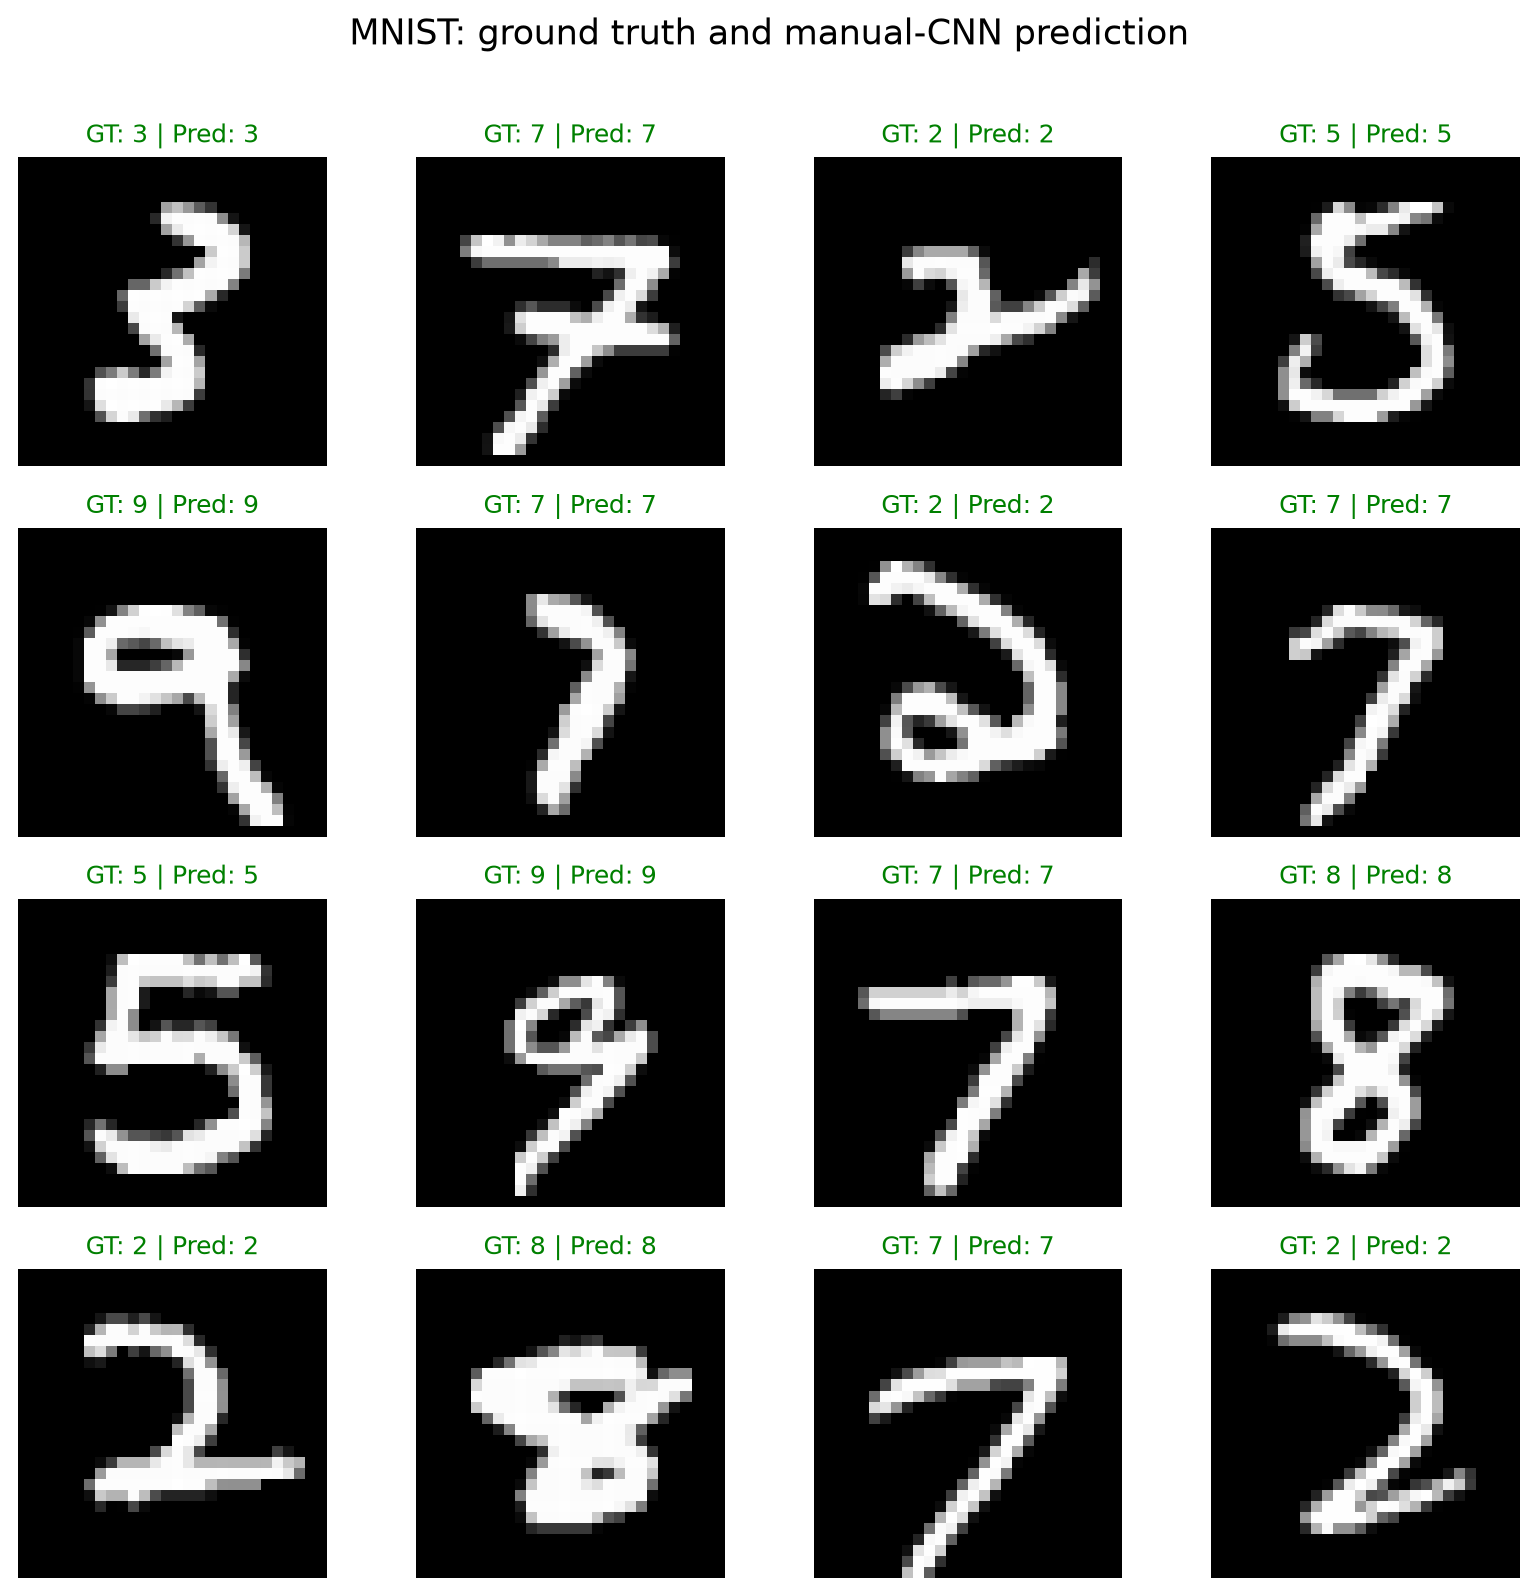

In [8]:
from IPython.display import Image, display

assert len(selected_indices) == 16
display(Image(filename=str(grid_path)))

## Training curves

The plots below show the loss and accuracy measured over the training
split after each full epoch.

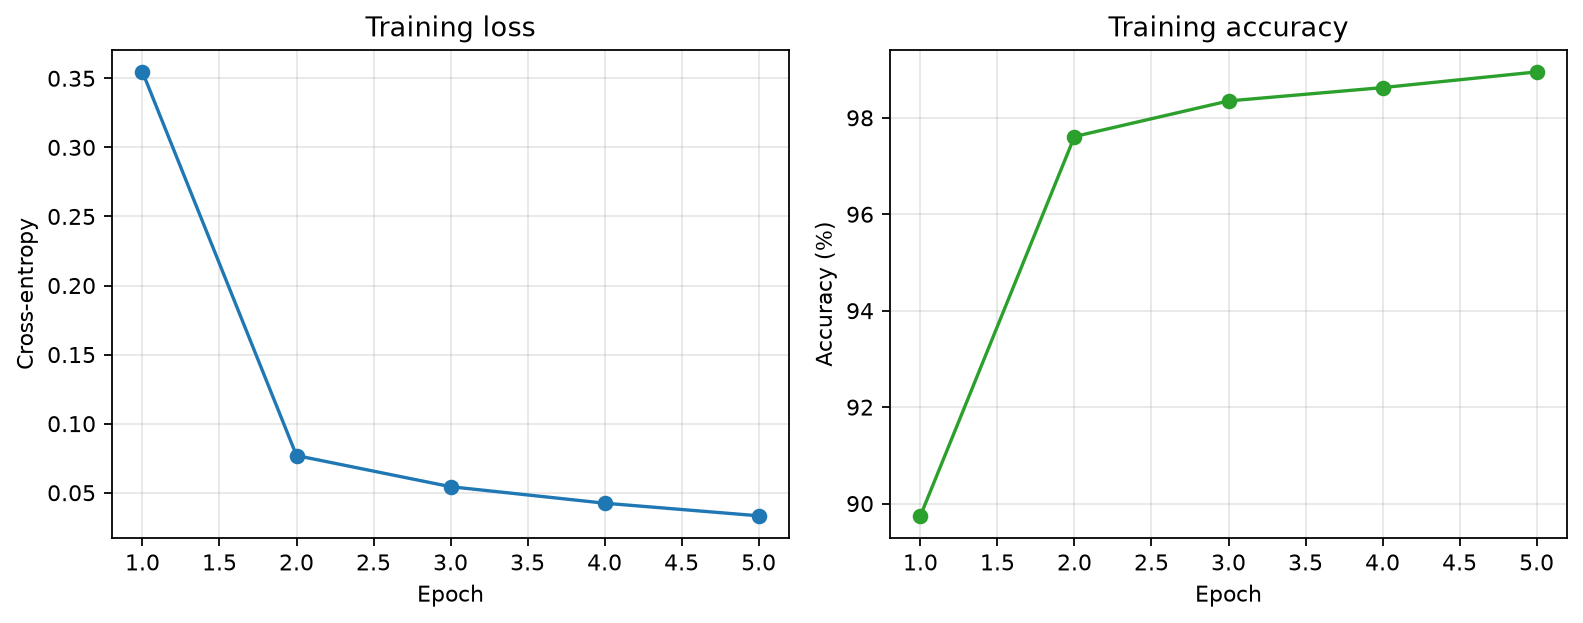

In [9]:
display(Image(filename=str(curves_path)))

## Compliance and interpretation summary

- Convolution: `as_strided` windows → Einops flattening → `einsum`.
- Pooling: `einops.reduce(..., "max")`.
- Dense layers: `einsum`.
- Activation and loss: elementary tensor operations.
- Optimizer: Adam updates the ordinary leaf tensors returned by the
  model's `parameters()` method.
- Dataset utility: torchvision MNIST reader only.
- CNN/NLP libraries: none.

The automated test suite also parses the ME1 source abstract syntax tree
to reject prohibited imports and layer constructors. Passing those tests
does not replace understanding: inspect the window strides, contraction
indices, shape trace, loss, epoch logs, test result, and prediction grid.